# Multi-Layer Perceptron (MLP) — Fashion-MNIST Classification

**Model Overview**

A Multi-Layer Perceptron is a feedforward artificial neural network consisting of an input layer, one or more hidden layers, and an output layer. Each neuron applies a weighted linear transformation followed by a non-linear activation function (ReLU). The network learns by minimizing a loss function (Cross-Entropy) via backpropagation with the Adam optimizer. L2 regularization (weight decay) penalizes large weights to reduce overfitting.

**Pipeline**

- **Stage 1 – Data Loading & Preprocessing**: Load processed CSVs → stratified train/valid split → StandardScaler normalization
- **Stage 2 – Sanity Checks**: Baseline (DummyClassifier) + overfit verification on tiny batch
- **Stage 3 – Model Definition**: Configurable PyTorch MLP with variable depth and width
- **Stage 4 – Hyperparameter Optimization**: Optuna (TPESampler + MedianPruner), 100 trials
- **Stage 5 – Convergence Evidence**: Optimization history and parameter importance plots
- **Stage 6 – Statistical Stability**: 5-seed re-evaluation (μ ± σ)
- **Stage 7 – Final Test Evaluation**: Hold-out test set, used once
- **Stage 8–9 – Analysis**: Quantitative comparison table + qualitative visualizations

## 0. Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import optuna
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

# Reproducibility
RANDOM_SEED = 42
SEEDS = [42, 5435, 123, 2026, 23]

def seed_everything(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(RANDOM_SEED)

# Visual style (matching EDA notebook)
%matplotlib inline
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## 1. Data Loading & Preprocessing

We load the processed CSVs exported from the EDA notebook. The 60,000 training samples are split into 54,000 for training and 6,000 for validation using stratified sampling (seed 42) to preserve class balance. 

**StandardScaler** is applied to transform pixel values from [0, 255] to zero mean and unit variance. This is critical for neural networks: without standardization, large raw pixel values cause gradient saturation in early layers, leading to slow or failed convergence of the Adam optimizer.

In [2]:
# --- Load Data ---
train_full_df = pd.read_csv('/kaggle/input/datasets/nguyendobao/fashion-mnist/data/processed/fashion_mnist_train_60k.csv')
test_df = pd.read_csv('/kaggle/input/datasets/nguyendobao/fashion-mnist/data/processed/fashion_mnist_test_10k.csv')
labels_df = pd.read_csv('/kaggle/input/datasets/nguyendobao/fashion-mnist/data/processed/labels.csv')

class_names = labels_df['class_name'].tolist()

X_full = train_full_df.drop('label', axis=1).values
y_full = train_full_df['label'].values
X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

# --- Stratified Split: 54k train / 6k valid (seed 42) ---
X_train, X_valid, y_train, y_valid = train_test_split(
    X_full, y_full, test_size=0.10, random_state=RANDOM_SEED, stratify=y_full
)

print("--- DATA SHAPES ---")
print(f"Training set  : {X_train.shape}")
print(f"Validation set: {X_valid.shape}")
print(f"Test set      : {X_test.shape}")

--- DATA SHAPES ---
Training set  : (54000, 784)
Validation set: (6000, 784)
Test set      : (10000, 784)


In [3]:
# --- StandardScaler: fit on train only ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_valid_scaled = scaler.transform(X_valid).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print("--- POST-SCALING VERIFICATION ---")
print(f"Train mean: {X_train_scaled.mean():.6f} (expected ~0)")
print(f"Train std : {X_train_scaled.std():.6f} (expected ~1)")

--- POST-SCALING VERIFICATION ---
Train mean: 0.000000 (expected ~0)
Train std : 1.000000 (expected ~1)


In [4]:
# --- PyTorch DataLoaders ---
BATCH_SIZE = 256

def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_scaled, y_train, shuffle=True)
valid_loader = make_loader(X_valid_scaled, y_valid)
test_loader = make_loader(X_test_scaled, y_test)

print(f"Train batches: {len(train_loader)}, Valid batches: {len(valid_loader)}, Test batches: {len(test_loader)}")

Train batches: 211, Valid batches: 24, Test batches: 40


## 2. Sanity Checks

Before investing compute in hyperparameter tuning, we verify two things:

1. **Baseline floor**: A `DummyClassifier(strategy='stratified')` establishes the minimum performance any real model must beat. With 10 perfectly balanced classes, we expect ~10% accuracy and F1.
2. **Logic verification**: We overfit a small MLP on just 50 training samples. If it cannot reach 100% training accuracy, the training loop is broken.

In [5]:
# --- 2.1 Baseline: DummyClassifier ---
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)
dummy.fit(X_train_scaled, y_train)
dummy_preds = dummy.predict(X_valid_scaled)

dummy_acc = accuracy_score(y_valid, dummy_preds)
dummy_f1 = f1_score(y_valid, dummy_preds, average='macro')

print("--- BASELINE (DummyClassifier) ---")
print(f"Accuracy : {dummy_acc:.4f}")
print(f"Macro-F1 : {dummy_f1:.4f}")
print("Any real model must significantly exceed these values.")

--- BASELINE (DummyClassifier) ---
Accuracy : 0.1008
Macro-F1 : 0.1009
Any real model must significantly exceed these values.


In [6]:
# --- 2.2 Logic Verification: Overfit on 50 samples ---
X_tiny = torch.tensor(X_train_scaled[:50], dtype=torch.float32).to(device)
y_tiny = torch.tensor(y_train[:50], dtype=torch.long).to(device)

tiny_mlp = nn.Sequential(
    nn.Linear(784, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
).to(device)

optimizer_tiny = optim.Adam(tiny_mlp.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(500):
    tiny_mlp.train()
    logits = tiny_mlp(X_tiny)
    loss = criterion(logits, y_tiny)
    optimizer_tiny.zero_grad()
    loss.backward()
    optimizer_tiny.step()

tiny_mlp.eval()
with torch.no_grad():
    preds = tiny_mlp(X_tiny).argmax(dim=1).cpu().numpy()
overfit_acc = accuracy_score(y_train[:50], preds)

print("--- LOGIC VERIFICATION ---")
print(f"Train accuracy on 50 samples: {overfit_acc:.4f}")
assert overfit_acc == 1.0, f"Expected 100% but got {overfit_acc:.2%}"
print("PASSED: Training loop can drive loss to zero.")

--- LOGIC VERIFICATION ---
Train accuracy on 50 samples: 1.0000
PASSED: Training loop can drive loss to zero.


## 3. Model Definition

We define a configurable MLP architecture and reusable training/evaluation functions. The architecture supports:
- **Variable depth** (1–3 hidden layers): tests whether deeper feature hierarchies help
- **Variable width** (32–512 units per layer): controls representational capacity
- **ReLU activations**: efficient non-linearity that avoids vanishing gradients
- **L2 regularization** via Adam's `weight_decay` parameter

In [7]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, num_classes=10):
        """
        Args:
            input_dim: number of input features (784)
            hidden_layers: list of ints, e.g. [256, 128] for 2 hidden layers
            num_classes: number of output classes (10)
        """
        super().__init__()
        layers = []
        prev_dim = input_dim
        for units in hidden_layers:
            layers.append(nn.Linear(prev_dim, units))
            layers.append(nn.ReLU())
            prev_dim = units
        layers.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, device):
    """Returns (all_preds, all_labels, all_probs) as numpy arrays."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(y_batch.numpy())
        all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels), np.concatenate(all_probs)


def compute_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='macro'),
        'recall': recall_score(y_true, y_pred, average='macro'),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
    }

print("Model and helpers defined.")

Model and helpers defined.


## 4. Hyperparameter Optimization (Optuna)

We use **Optuna** with the **TPE (Tree-structured Parzen Estimator)** sampler for Bayesian optimization of the MLP hyperparameters. The search space (from the experimental setup draft):

| Hyperparameter | Range | Scale | Justification |
|---|---|---|---|
| `n_layers` | 1–3 | integer | 1 layer = shallow baseline; 3 = deeper feature hierarchies |
| `n_units_l{i}` | 32–512 | integer | 32 = minimal; 512 = rich feature maps |
| `weight_decay` (α) | [10⁻⁵, 10⁻¹] | log | L2 regularization strength; log scale due to multiplicative effect |
| `learning_rate` | [10⁻⁴, 10⁻²] | log | Adam step size; too small → slow, too large → divergence |

- **Objective**: Maximize `f1_macro` on the 6k validation set
- **Budget**: 100 trials
- **Pruner**: `MedianPruner` terminates underperforming trials early (per-epoch reporting)
- **Max epochs per trial**: 50, with early stopping (patience=5)

In [8]:
MAX_EPOCHS_OPTUNA = 50
PATIENCE = 5
N_TRIALS = 100

def objective(trial):
    # --- Sample hyperparameters ---
    n_layers = trial.suggest_int('n_layers', 1, 3)
    hidden_layers = []
    for i in range(n_layers):
        units = trial.suggest_int(f'n_units_l{i}', 32, 512)
        hidden_layers.append(units)

    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-1, log=True)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    # --- Build model ---
    seed_everything(RANDOM_SEED)
    model = MLP(784, hidden_layers).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    # --- Train with early stopping + pruning ---
    best_f1 = 0.0
    patience_counter = 0

    for epoch in range(MAX_EPOCHS_OPTUNA):
        train_one_epoch(model, train_loader, criterion, optimizer, device)
        preds, labels, _ = evaluate(model, valid_loader, device)
        f1 = f1_score(labels, preds, average='macro')

        # Report to Optuna for pruning
        trial.report(f1, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        # Early stopping
        if f1 > best_f1:
            best_f1 = f1
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    return best_f1

print(f"Objective defined. Will run {N_TRIALS} trials, up to {MAX_EPOCHS_OPTUNA} epochs each.")

Objective defined. Will run 100 trials, up to 50 epochs each.


In [9]:
# --- Run Optuna Study ---
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=10)
)

print(f"Starting Optuna optimization ({N_TRIALS} trials)...")
t_start = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
optuna_time = time.time() - t_start

print(f"\nOptuna completed in {optuna_time / 60:.1f} minutes")
print(f"Best Macro-F1: {study.best_trial.value:.4f}")
print(f"Best params: {study.best_trial.params}")

Starting Optuna optimization (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]


Optuna completed in 22.3 minutes
Best Macro-F1: 0.9106
Best params: {'n_layers': 2, 'n_units_l0': 272, 'n_units_l1': 385, 'weight_decay': 1.3249075661005958e-05, 'learning_rate': 0.0008052826616069019}


## 5. Convergence Evidence

To prove the trial budget (100 trials) was sufficient, we plot the **Optimization History** — the best score should plateau, meaning additional trials would not yield meaningful improvement. We also plot **Parameter Importances** to understand which hyperparameters had the largest impact on performance.

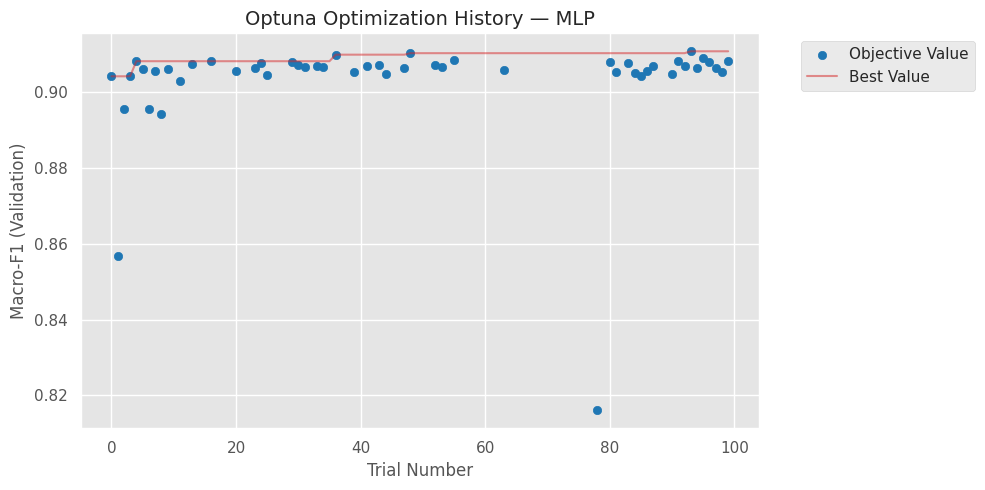

In [10]:
# --- 5.1 Optimization History ---
ax = plot_optimization_history(study)
ax.set_title("Optuna Optimization History — MLP", fontsize=14)
ax.set_xlabel("Trial Number")
ax.set_ylabel("Macro-F1 (Validation)")
ax.get_figure().set_size_inches(10, 5)
plt.tight_layout()
plt.show()

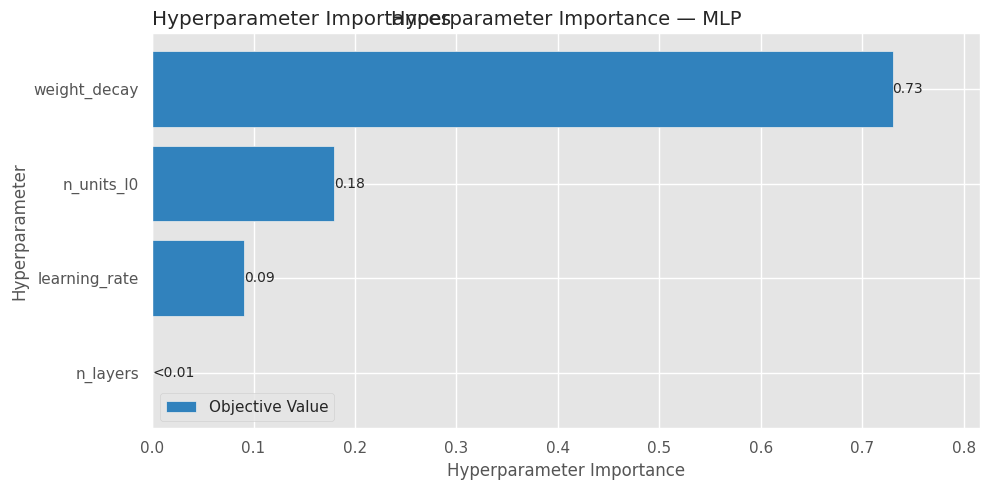

In [11]:
# --- 5.2 Parameter Importances ---
ax = plot_param_importances(study)
ax.set_title("Hyperparameter Importance — MLP", fontsize=14)
ax.get_figure().set_size_inches(10, 5)
plt.tight_layout()
plt.show()

## 6. Statistical Stability Check (5-Seed Re-evaluation)

A single training run is insufficient to claim robust performance — neural network training is stochastic due to random weight initialization and mini-batch shuffling. We retrain the best configuration from Optuna with 5 different seeds and report μ ± σ for all metrics. Low standard deviation proves the configuration is robust and not the result of a lucky seed.

In [12]:
# --- Extract best hyperparameters ---
best_params = study.best_trial.params
n_layers_best = best_params['n_layers']
hidden_layers_best = [best_params[f'n_units_l{i}'] for i in range(n_layers_best)]
wd_best = best_params['weight_decay']
lr_best = best_params['learning_rate']

print("--- BEST CONFIGURATION ---")
print(f"Hidden layers: {hidden_layers_best}")
print(f"Weight decay : {wd_best:.6f}")
print(f"Learning rate: {lr_best:.6f}")

# --- 5-Seed Re-evaluation ---
MAX_EPOCHS_FINAL = 100
stability_results = []

for seed in SEEDS:
    seed_everything(seed)
    model = MLP(784, hidden_layers_best).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr_best, weight_decay=wd_best)
    criterion = nn.CrossEntropyLoss()

    best_f1 = 0.0
    patience_counter = 0

    t_start = time.time()
    for epoch in range(MAX_EPOCHS_FINAL):
        train_one_epoch(model, train_loader, criterion, optimizer, device)
        preds, labels, _ = evaluate(model, valid_loader, device)
        f1 = f1_score(labels, preds, average='macro')

        if f1 > best_f1:
            best_f1 = f1
            best_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    train_time = time.time() - t_start

    # Reload best checkpoint for this seed
    model.load_state_dict(best_state)
    preds, labels, _ = evaluate(model, valid_loader, device)
    metrics = compute_metrics(labels, preds)
    metrics['train_time'] = train_time
    metrics['seed'] = seed
    stability_results.append(metrics)

    print(f"Seed {seed}: F1={metrics['f1_macro']:.4f}, Time={train_time:.1f}s")

stability_df = pd.DataFrame(stability_results)
print("\n--- STABILITY RESULTS ---")
display(stability_df)

--- BEST CONFIGURATION ---
Hidden layers: [272, 385]
Weight decay : 0.000013
Learning rate: 0.000805
Seed 42: F1=0.9051, Time=19.1s
Seed 5435: F1=0.9047, Time=17.7s
Seed 123: F1=0.9038, Time=19.5s
Seed 2026: F1=0.8990, Time=14.3s
Seed 23: F1=0.9031, Time=12.5s

--- STABILITY RESULTS ---


,accuracy,precision,recall,f1_macro,train_time,seed
0,0.905667,0.905690,0.905667,0.905070,19.116228,42
1,0.904500,0.904943,0.904500,0.904686,17.732757,5435
2,0.904000,0.904018,0.904000,0.903765,19.456893,123
3,0.900000,0.901476,0.900000,0.899000,14.280252,2026
4,0.903000,0.903905,0.903000,0.903079,12.455072,23


In [13]:
# --- Summary: μ ± σ ---
metric_cols = ['accuracy', 'precision', 'recall', 'f1_macro', 'train_time']
summary = stability_df[metric_cols].agg(['mean', 'std'])

# Format as μ ± σ
summary_formatted = {}
for col in metric_cols:
    mu, sigma = summary[col]['mean'], summary[col]['std']
    if col == 'train_time':
        summary_formatted[col] = f"{mu:.1f} ± {sigma:.1f} s"
    else:
        summary_formatted[col] = f"{mu:.4f} ± {sigma:.4f}"

print("--- VALIDATION PERFORMANCE (μ ± σ across 5 seeds) ---")
for k, v in summary_formatted.items():
    print(f"  {k:12s}: {v}")

--- VALIDATION PERFORMANCE (μ ± σ across 5 seeds) ---
  accuracy    : 0.9034 ± 0.0021
  precision   : 0.9040 ± 0.0016
  recall      : 0.9034 ± 0.0021
  f1_macro    : 0.9031 ± 0.0024
  train_time  : 16.6 ± 3.1 s


## 7. Final Test Set Evaluation

The hold-out test set (10,000 samples) is used **exactly once** to produce the final unbiased performance report. The model is trained with the best configuration and seed 42.

In [14]:
# --- Train final model (seed 42, best params) ---
seed_everything(RANDOM_SEED)
final_model = MLP(784, hidden_layers_best).to(device)
final_optimizer = optim.Adam(final_model.parameters(), lr=lr_best, weight_decay=wd_best)
criterion = nn.CrossEntropyLoss()

best_f1 = 0.0
patience_counter = 0
best_state = None

for epoch in range(MAX_EPOCHS_FINAL):
    train_one_epoch(final_model, train_loader, criterion, final_optimizer, device)
    preds, labels, _ = evaluate(final_model, valid_loader, device)
    f1 = f1_score(labels, preds, average='macro')

    if f1 > best_f1:
        best_f1 = f1
        best_state = final_model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch + 1}")
            break

final_model.load_state_dict(best_state)
print(f"Final model trained. Best validation F1: {best_f1:.4f}")

Early stopping at epoch 23
Final model trained. Best validation F1: 0.9106


In [15]:
# --- Test set evaluation (used once) ---
test_preds, test_labels, test_probs = evaluate(final_model, test_loader, device)
test_metrics = compute_metrics(test_labels, test_preds)

print("--- FINAL TEST SET RESULTS ---")
print(classification_report(test_labels, test_preds, target_names=class_names))

# --- Inference time ---
# Warm-up
_ = evaluate(final_model, test_loader, device)

t_start = time.time()
for _ in range(10):
    _ = evaluate(final_model, test_loader, device)
total_time = time.time() - t_start
avg_inference_ms = (total_time / (10 * len(y_test))) * 1000

print(f"\nAverage inference time per image: {avg_inference_ms:.4f} ms")

--- FINAL TEST SET RESULTS ---
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.88      0.84      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.81      0.82      0.82      1000
       Dress       0.90      0.87      0.89      1000
        Coat       0.79      0.87      0.83      1000
      Sandal       0.97      0.96      0.96      1000
       Shirt       0.78      0.65      0.71      1000
     Sneaker       0.92      0.98      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.98      0.94      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Average inference time per image: 0.0096 ms


## 8. Quantitative Analysis

In [16]:
# --- Master Comparison Table ---
master_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'Macro-F1', 'Training Time', 'Inference (ms/img)'],
    'Validation (μ ± σ)': [
        summary_formatted['accuracy'],
        summary_formatted['precision'],
        summary_formatted['recall'],
        summary_formatted['f1_macro'],
        summary_formatted['train_time'],
        '—'
    ],
    'Test': [
        f"{test_metrics['accuracy']:.4f}",
        f"{test_metrics['precision']:.4f}",
        f"{test_metrics['recall']:.4f}",
        f"{test_metrics['f1_macro']:.4f}",
        '—',
        f"{avg_inference_ms:.4f}"
    ]
})

print("--- MLP MASTER COMPARISON TABLE ---")
display(master_table)

--- MLP MASTER COMPARISON TABLE ---


,Metric,Validation (μ ± σ),Test
0,Accuracy,0.9034 ± 0.0021,0.8903
1,Precision,0.9040 ± 0.0016,0.8909
2,Recall,0.9034 ± 0.0021,0.8903
3,Macro-F1,0.9031 ± 0.0024,0.8895
4,Training Time,16.6 ± 3.1 s,—
5,Inference (ms/img),—,0.0096


## 9. Qualitative Analysis

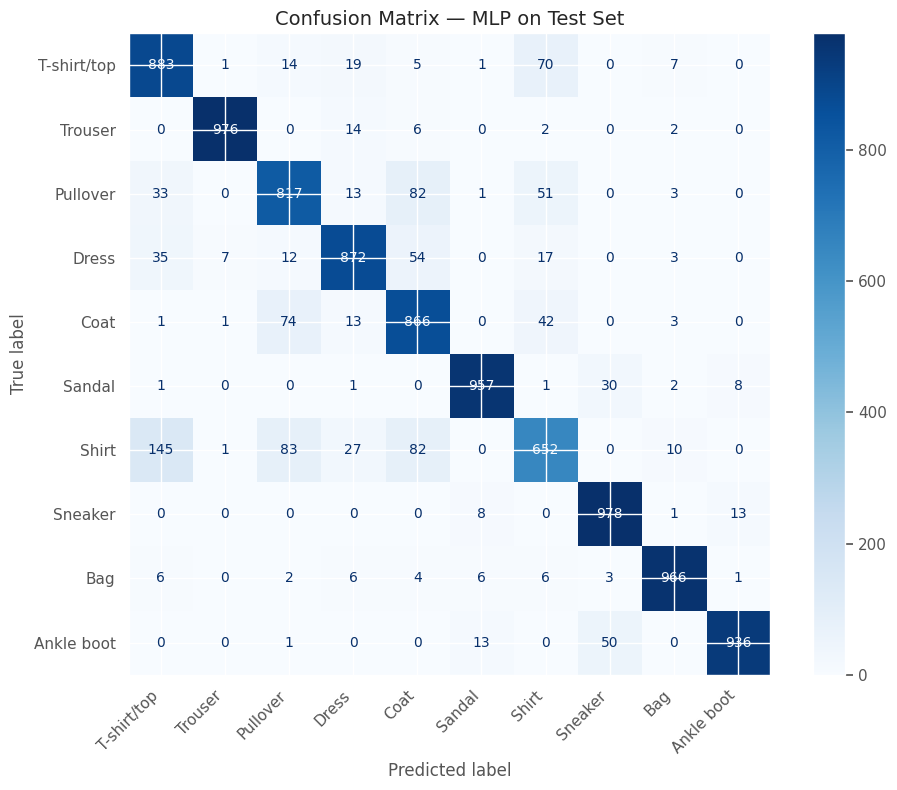

In [17]:
# --- 9.1 Confusion Matrix ---
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title("Confusion Matrix — MLP on Test Set", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

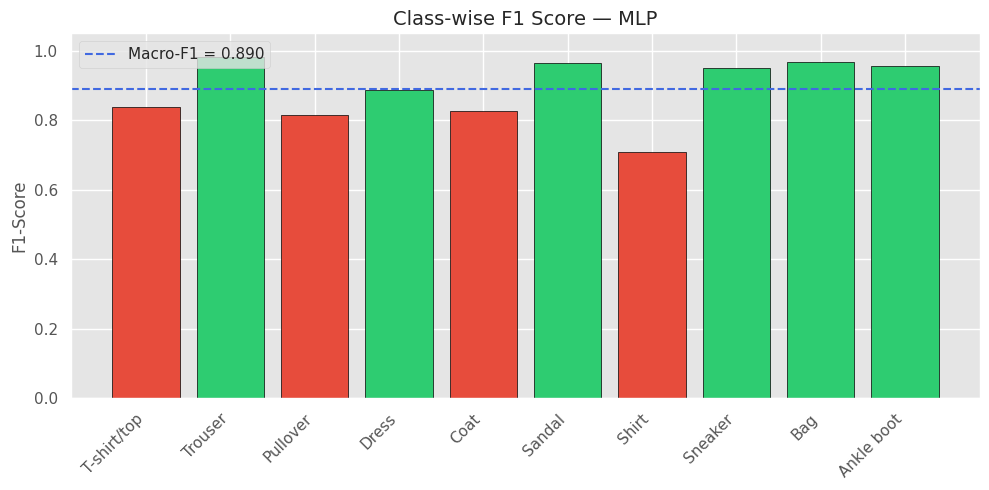

In [18]:
# --- 9.2 Class-wise F1-Score ---
report_dict = classification_report(test_labels, test_preds, target_names=class_names, output_dict=True)
class_f1 = [report_dict[name]['f1-score'] for name in class_names]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if f < 0.85 else '#2ecc71' for f in class_f1]
ax.bar(class_names, class_f1, color=colors, edgecolor='black')
ax.axhline(y=np.mean(class_f1), color='royalblue', linestyle='--',
           label=f'Macro-F1 = {np.mean(class_f1):.3f}')
ax.set_ylabel('F1-Score')
ax.set_title('Class-wise F1 Score — MLP', fontsize=14)
ax.set_ylim(0, 1.05)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()